In [7]:
%load_ext autoreload
%autoreload 2

# Importing the modules

    
import config_2Dcoupling_V2 as cfg              # config = physical & simulation parameters 
from solver_Hcurl_2D_V2 import *                # solver = mesh build, physics import and FEM method + pmls initialization
import Post_Process_V2_Run_n_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import Post_Process_V2_Load_n_Plot as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__)

In [3]:
mesh_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Meshes")
mesh_save_dir.mkdir(parents=True, exist_ok=True)

figure_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Figures")
figure_save_dir.mkdir(parents=True, exist_ok=True)


solver.build_physics_Stix_B_field(lambda x, z: pp_run.create_density_profile(x, z, solver))
mesh = solver.build_mesh_with_PMLs(mesh_save_dir)
# print('num_vertices = ', mesh.nv)

GF_E_field, _ = solver.solve_helmholtz_Hcurl_2D_pml(mesh, cfg)

ne = 3e+18, type(ne) = <class 'float'>

[MESH BUILDER] :
  --> SW n_perp_p : 6.94753e+00, n_perp_m = 1.00000e-03
  --> SW lambda_perp : 1.16624e-02 m, lambda_para = 4.05125e-02 m
  --> Lx_plm = 1.00000e-02 m, Lx_tot = 5.00000e-02 m
  --> Lz_plasma : 4.05125e-02 m
  --> h_max resolution : 1.45780e-03 m
#DoFs = 20945 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---


In [5]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260527_131337
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260527_105312


--- Extracting 2D Wave Map ---
params recover in run_2D_wave_map
--- 2D Map saved to /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260527_105312/Wave_Map_2D.h5 ---
--- Plotting 2D Map from /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260527_105312/Wave_Map_2D.h5 ---


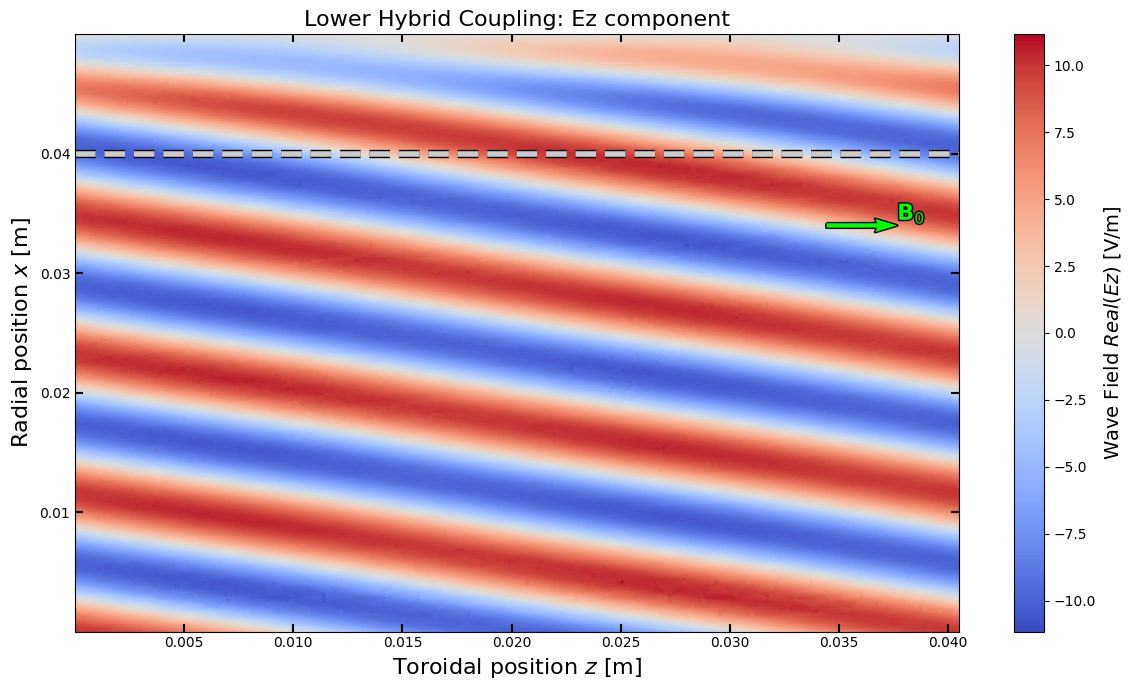

In [5]:
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path)
# Plot E field 2D map and save it in the same folder: Run_XXX 
pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, component='Ez', value_type='real', plot_e_vectors=False)

In [6]:
# E_radial_profile_h5_filepath = pp_run.run_1D_radial_profile(mesh, GF_E_field, cfg, run_folder_tot_path)
# pp_plot.plot_1D_radial_benchmark(E_radial_profile_h5_filepath, run_folder_tot_path, component='Ex')
# pp_plot.plot_1D_radial_benchmark(E_radial_profile_h5_filepath, run_folder_tot_path, component='Ey')
# pp_plot.plot_1D_radial_benchmark(E_radial_profile_h5_filepath, run_folder_tot_path, component='Ez')

In [ ]:
h5_file_path = pp_run.run_pml_scan_dataset(solver, cfg, run_folder_tot_path)

--- Initiating ULTIMATE 7D Sobol Data Lake: 4096 Simulations ---



Run 1/4096 | 
Lx_pml:19.8λ_perp, Sx_r:3.4, Sx_im:3.0, px:1.7
, n//:7.38, ne:5.5e+18



[MESH BUILDER] :
  --> SW n_perp_p : 4.01801e+01, n_perp_m = 1.00000e-03
  --> SW lambda_perp : 2.01655e-03 m, lambda_para = 1.09734e-02 m
  --> Lx_plm = 3.99305e-02 m, Lx_tot = 4.39602e-02 m
  --> Lz_plasma : 1.09734e-02 m
  --> h_max resolution : 2.52068e-04 m
#DoFs = 171730 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---
  --> Success | Gamma_Radial: 9.07e-03 
--- Run ok & data saved correctly ---



Run 2/4096 | 
Lx_pml:13.7λ_perp, Sx_r:1.6, Sx_im:5.9, px:2.3
, n//:3.14, ne:9.5e+17



[MESH BUILDER] :
  --> SW n_perp_p : 6.34258e+00, n_perp_m = 1.00000e-03
  --> SW lambda_perp : 1.27748e-02 m, lambda_para = 2.58324e-02 m
  --> Lx_plm = 1.75314e-01 m, Lx_tot = 2.00838e-01 m
  --> Lz_plasma : 2.58324e-02 m
  --> h_max resolution : 1.59685e-03 m
#DoFs = 45836 (= number of mesh points).
--

no more timer available (FESpace), reusing last one


--- System solved ---
  --> Success | Gamma_Radial: 6.35e-02 
--- Run ok & data saved correctly ---



Run 899/4096 | 
Lx_pml:17.3λ_perp, Sx_r:1.5, Sx_im:7.2, px:2.8
, n//:5.50, ne:9.5e+18



[MESH BUILDER] :
  --> SW n_perp_p : 3.89372e+01, n_perp_m = 1.00000e-03
  --> SW lambda_perp : 2.08091e-03 m, lambda_para = 1.47313e-02 m
  --> Lx_plm = 3.60021e-02 m, Lx_tot = 4.01605e-02 m
  --> Lz_plasma : 1.47313e-02 m
  --> h_max resolution : 2.60114e-04 m
#DoFs = 195274 (= number of mesh points).
--- Solving the 3D vector linear system ---
--- System solved ---
  --> Success | Gamma_Radial: 4.02e-03 
--- Run ok & data saved correctly ---



Run 900/4096 | 
Lx_pml:11.2λ_perp, Sx_r:3.5, Sx_im:4.3, px:1.9
, n//:9.74, ne:5.1e+17



[MESH BUILDER] :
  --> SW n_perp_p : 1.36476e+01, n_perp_m = 1.00000e-03
  --> SW lambda_perp : 5.93693e-03 m, lambda_para = 8.32275e-03 m
  --> Lx_plm = 6.66355e-02 m, Lx_tot = 7.84946e-02 m
  --> Lz_plasma : 8.32275e-03 m
  --> h_max resolution : 7.42116e-04 m
#DoF

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from Post_Process_V3_Explore_Data import PMLDataExplorer

explorer_data_file = "/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V2_(radial_pml_only)/Simulation_Results/Run_20260522_105312/PML_scan_all_param_dataset.h5"

# explorer_data_file = run_folder_tot_path + "/" + h5_file_path
print(explorer_data_file)
explorer = PMLDataExplorer(explorer_data_file)

display(explorer.df.describe())

ModuleNotFoundError: No module named 'Post_Process_V3_Explore_Data'

In [ ]:
explorer.plot_universal_scatter(
    x_var = 'S_imag', 
    y_var='Gamma_E', 
    color_var='n_para',
    filter_query="Gamma_S < 0.0005"
)

In [ ]:
import seaborn as sns 
import pandas as pd
import h5py

#print(df.keys())
with h5py.File(explorer_data_file, 'r') as h5f:
    data_dict = {key: h5f[key][:] for key in h5f.keys()}

df = pd.DataFrame(data_dict)
df = df.query('Gamma_E < 0.99').copy()
 
corr_matrix = df[['Gamma_E', 'S_real', 'S_imag', 'p_degree', 'L_pml_ratio', 'CPU_Time', 'n_para', 'n_e']].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidth=.5)

In [ ]:
best_run_df = df.query('Gamma_E < 0.0003')
# sns.pairplot(best_run_df, vars=['Gamma_E', 'S_real', 'S_imag', 'L_pml_ratio', 'n_para', 'n_e'], diag_kind='kde', plot_kws={'alpha':0.6})
# plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load clean dataset
clean_df = df.query("0 < Gamma_E < 0.90").copy()
clean_df['n_e_log'] = np.log10(clean_df['n_e']) 
features = ['S_imag', 'L_pml_ratio', 'S_real', 'p_degree', 'n_para', 'n_e_log']

X = clean_df[features].values              # X = inputs of the model 
Y = np.log10(clean_df['Gamma_E'].values)   # Y = outputs
 
print(f"Valid runs for training: {len(clean_df)}")

# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, train_size=2000, random_state=42)

# Generating the kernel
physics_kernel = C(1.0) * Matern(length_scale=[1.0] * len(features), nu=2.5)
noise_kernel = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1.0))
full_kernel = physics_kernel + noise_kernel

# GPR Configuration
gpr = GaussianProcessRegressor(
    kernel=full_kernel, 
    n_restarts_optimizer=10, 
    normalize_y=True, 
    random_state=42
)

print("Training Noise-Adaptive GPR (This may take 1-2 minutes)...")
gpr.fit(X_train, y_train)

# 8. Validation
y_pred_test = gpr.predict(X_test)
r2 = r2_score(y_test, y_pred_test)

print(f"\n[VALIDATION] GPR R^2 Score on unseen data: {r2:.4f}")

In [ ]:
if r2 > 0.85:
    print("\n[SUCCESS] The model successfully mapped the physics and ignored the mode-mixing noise.")
    
    # Print the learned length scales
    learned_scales = gpr.kernel_.k1.k2.length_scale
    print("\nLearned Length Scales (Smaller = Higher Physical Impact):")
    for name, scale in zip(features, learned_scales):
        print(f"{name:12}: {scale:.2f}")

In [ ]:
from scipy.stats import qmc
sweep_size = 100000
sampler = qmc.Sobol(d=len(bounds), scramble=True)
mc_raw = sampler.random_base2(m=14)
# print(f'mc_raw: {mc_raw}')
bounds = {
        'S_imag': [0.5, 10.0],
        'L_pml_ratio': [4.0, 10.0],
        'p_degree': [1.5, 3.0],
        'S_real': [1.0, 10.0],
        'n_para':[1.1, 100],
        'n_e_log': [np.log10(5e17), np.log10(5e19)]}

X_mc = np.zeros_like(mc_raw)
for i, key in enumerate(features):
    print(f'i: {i} => key: {key}')
    lb, ub = bounds[key]
    X_mc[:, i] = lb + mc_raw[:, i] * (ub - lb)
# print(f'X_mc: {X_mc}')

X_mc_scaled = scaler.transform(X_mc)
mu_log, sigma_log = gpr.predict(X_mc_scaled, return_std=True)
# print(f'sigma_log: {sigma_log}')

ucb_log = mu_log + (1.96 * sigma_log) # 1.96*sigma = 95% of confidence
# print(f'ucb_log : {ucb_log}')


# Convert back from log to linear space
UCB_linear = 10**ucb_log

# filter refl coeff
threshold = 7e-4
safe_indices = np.where(UCB_linear <= threshold)[0]

if len(safe_indices) == 0:
        print(f"[!] No parameters guarantee Gamma_E < {threshold} under 95% certainty.")
else:
    safe_points = X_mc[safe_indices]
    safe_df = pd.DataFrame(safe_points, columns=features)
        
    print(f"Found {len(safe_indices)} configurations guaranteeing Gamma_E < {threshold}.")
    print("\n--- ROBUST OPERATING BOUNDARIES ---")
    for col in features:
        val_min = safe_df[col].min()
        val_max = safe_df[col].max()
        # MUST ADD A VARIANCE COMPUTATION !!
        print(f"{col:12} : Range [{val_min:.2f}  to  {val_max:.2f}]")
print("\n")


In [ ]:
from SALib.sample import saltelli
from SALib.analyze import sobol

print("=== PHASE 3: GLOBAL SENSITIVITY ANALYSIS (SOBOL INDICES) ===")
# 1. Define the Problem for SALib
problem = {
    'num_vars': len(features),
    'names': features,
    'bounds': [bounds[f] for f in features]
}
    
# 2. Generate Saltelli Samples (Required for variance decomposition)
# 1024 base samples yields 1024 * (2D + 2) = 10,240 evaluations
X_salib = saltelli.sample(problem, 1024)
    
# 3. Evaluate samples using our GPR
X_salib_scaled = scaler.transform(X_salib)
y_salib_log = gpr.predict(X_salib_scaled) # We analyze the mean prediction
    
# 4. Compute Sobol Indices
Si = sobol.analyze(problem, y_salib_log, print_to_console=False)
    
print("--- VARIANCE DECOMPOSITION RESULTS ---")
for i, name in enumerate(features):
    S1 = Si['S1'][i]  # First-Order (Main effect of this parameter alone)
    ST = Si['ST'][i]  # Total-Order (Effect including interactions with others)
    print(f"{name:12} | Main Effect (S1): {S1*100:5.1f}% | Total Effect (ST): {ST*100:5.1f}%")
        
print("\n[CONCLUSION] If S1 is near 0%, the parameter does not independently drive the physics.")
print("If ST is large but S1 is small, the parameter is highly coupled to another variable.")



In [ ]:
# mesh_conv_h5_filepath = pp_run.run_mesh_convergence(solver, cfg, run_folder_tot_path)

In [ ]:
# pp_plot.plot_mesh_convergence(mesh_conv_h5_filepath, run_folder_tot_path)

In [ ]:
# Pour faire des boucles sur les params de config_dict

cfg.DOMAIN['Lx_plasma'] = 30.
print(cfg.DOMAIN['Lx_plasma'] )

